## Level 5: Model Comparison and User Testing

### Objective

To compare a basic machine learning model using one input feature with an improved model using multiple input features.

The models will be evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE), and their predictions will be compared using visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
train_journey = pd.read_csv("train_journey_cleaned.csv")
train_journey.head()


,Train_No,Start_Station,End_Station,Total_Distance,Number_of_Stops,Journey_Duration
0,107,SAWANTWADI R,MADGOAN JN.,78,4,105.0
1,108,MADGOAN JN.,SAWANTWADI R,83,4,115.0
2,128,MADGOAN JN.,CHHATRAPATI,978,22,1325.0
3,290,DELHI-SAFDAR,DELHI-SAFDAR,2694,14,480.0
4,401,AURANGABAD,VARANASI JN.,1618,12,750.0


In [4]:
print("Dataset Shape:", train_journey.shape)
print("\nMissing Values:")
print(train_journey.isnull().sum())


Dataset Shape: (11113, 6)

Missing Values:
Train_No            0
Start_Station       0
End_Station         0
Total_Distance      0
Number_of_Stops     0
Journey_Duration    0
dtype: int64


In [6]:
y = train_journey["Journey_Duration"]
print("Target variable:")
print(y.head())
y

Target variable:
0     105.0
1     115.0
2    1325.0
3     480.0
4     750.0
Name: Journey_Duration, dtype: float64


0         105.0
1         115.0
2        1325.0
3         480.0
4         750.0
          ...  
11108      50.0
11109      43.0
11110      50.0
11111      52.0
11112      50.0
Name: Journey_Duration, Length: 11113, dtype: float64

In [7]:
X_basic = train_journey[["Total_Distance"]]
X_basic.head()


,Total_Distance
0,78
1,83
2,978
3,2694
4,1618


In [11]:
X_basic_train, X_basic_test, y_basic_train, y_basic_test = train_test_split(
    X_basic,
    y,
    test_size=0.20,
    random_state=42
)

print("Basic Model Training Records:", len(X_basic_train))
print("Basic Model Testing Records:", len(X_basic_test))

Basic Model Training Records: 8890
Basic Model Testing Records: 2223


In [14]:
from sklearn.linear_model import LinearRegression
basic_model = LinearRegression()

basic_model.fit(
    X_basic_train,
    y_basic_train
)
print("Basic model trained successfully!")

Basic model trained successfully!


In [15]:
y_basic_pred = basic_model.predict(X_basic_test)

print("First 10 Actual Values:")
print(y_basic_test.head(10).values)

print("\nFirst 10 Predicted Values:")
print(y_basic_pred[:10])

First 10 Actual Values:
[ 690.  180.   55.  190.  113.   38.  450.   59.  705. 1185.]

First 10 Predicted Values:
[323.61591016 199.69407942 166.33050961 183.01229452 180.62918239
 164.62828666 286.50744986 169.73495551 735.21341941 666.44361224]


In [16]:
basic_mae = mean_absolute_error(
    y_basic_test,
    y_basic_pred
)
print("Basic Model MAE:", basic_mae)

Basic Model MAE: 168.80201669299055


In [17]:
basic_rmse = np.sqrt(
    mean_squared_error(
        y_basic_test,
        y_basic_pred
    )
)
print("Basic Model RMSE:", basic_rmse)

Basic Model RMSE: 247.05944958215466


In [18]:
X_improved = train_journey[
    ["Total_Distance", "Number_of_Stops"]
]
X_improved.head()

,Total_Distance,Number_of_Stops
0,78,4
1,83,4
2,978,22
3,2694,14
4,1618,12


In [19]:
X_improved_train, X_improved_test, y_improved_train, y_improved_test = train_test_split(
    X_improved,
    y,
    test_size=0.20,
    random_state=42
)
print("Improved Model Training Records:", len(X_improved_train))
print("Improved Model Testing Records:", len(X_improved_test))

Improved Model Training Records: 8890
Improved Model Testing Records: 2223


In [20]:
improved_model = LinearRegression()
improved_model.fit(
    X_improved_train,
    y_improved_train
)
print("Improved model trained successfully!")

Improved model trained successfully!


In [21]:
y_improved_pred = improved_model.predict(
    X_improved_test
)
print("First 10 Actual Values:")
print(y_improved_test.head(10).values)
print("\nFirst 10 Predicted Values:")
print(y_improved_pred[:10])

First 10 Actual Values:
[ 690.  180.   55.  190.  113.   38.  450.   59.  705. 1185.]

First 10 Predicted Values:
[368.70712897 262.12835    195.54327945 129.65859509 246.74881703
  94.99288723 292.48926408  92.50059034 707.3520751  526.25142439]


In [22]:
improved_mae = mean_absolute_error(
    y_improved_test,
    y_improved_pred
)
print("Improved Model MAE:", improved_mae)

Improved Model MAE: 152.21215044404454


In [23]:
improved_rmse = np.sqrt(
    mean_squared_error(
        y_improved_test,
        y_improved_pred
    )
)
print("Improved Model RMSE:", improved_rmse)

Improved Model RMSE: 237.38671754227823


In [24]:
model_comparison = pd.DataFrame({
    "Model": [
        "Basic Model",
        "Improved Model"
    ],
    "Features": [
        "Total_Distance",
        "Total_Distance + Number_of_Stops"
    ],
    "MAE": [
        basic_mae,
        improved_mae
    ],
    "RMSE": [
        basic_rmse,
        improved_rmse
    ]
})

model_comparison

,Model,Features,MAE,RMSE
0,Basic Model,Total_Distance,168.802017,247.059450
1,Improved Model,Total_Distance + Number_of_Stops,152.212150,237.386718


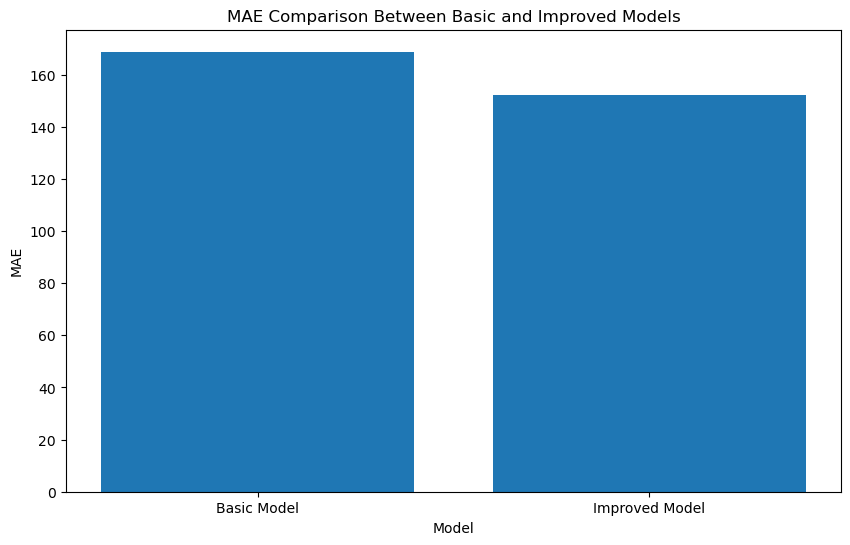

In [25]:
plt.figure(figsize=(10, 6))

plt.bar(
    ["Basic Model", "Improved Model"],
    [basic_mae, improved_mae]
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("MAE Comparison Between Basic and Improved Models")
plt.show()

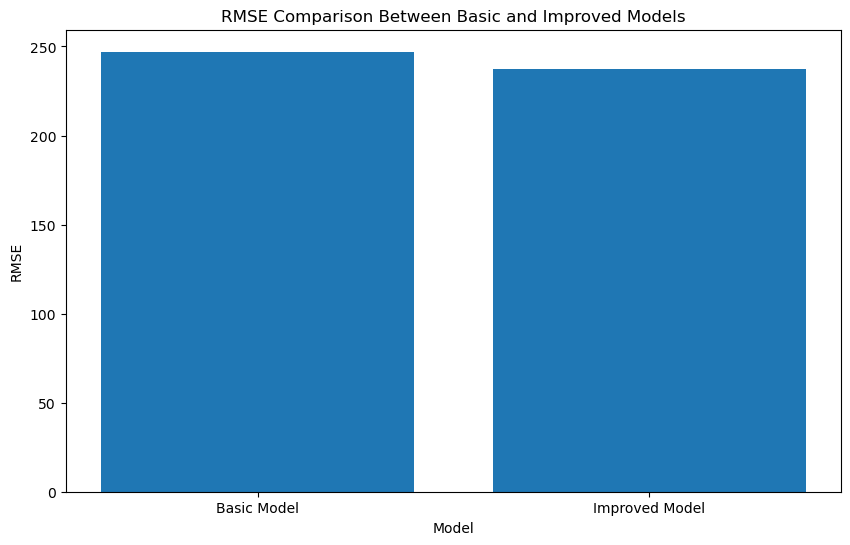

In [26]:
plt.figure(figsize=(10, 6))

plt.bar(
    ["Basic Model", "Improved Model"],
    [basic_rmse, improved_rmse]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("RMSE Comparison Between Basic and Improved Models")

plt.show()

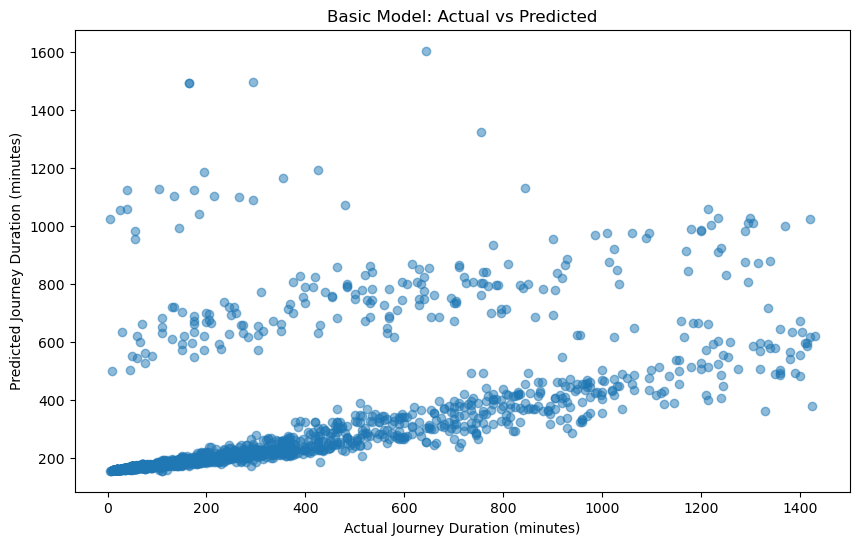

In [27]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_basic_test,
    y_basic_pred,
    alpha=0.5
)

plt.xlabel("Actual Journey Duration (minutes)")
plt.ylabel("Predicted Journey Duration (minutes)")
plt.title("Basic Model: Actual vs Predicted")

plt.show()

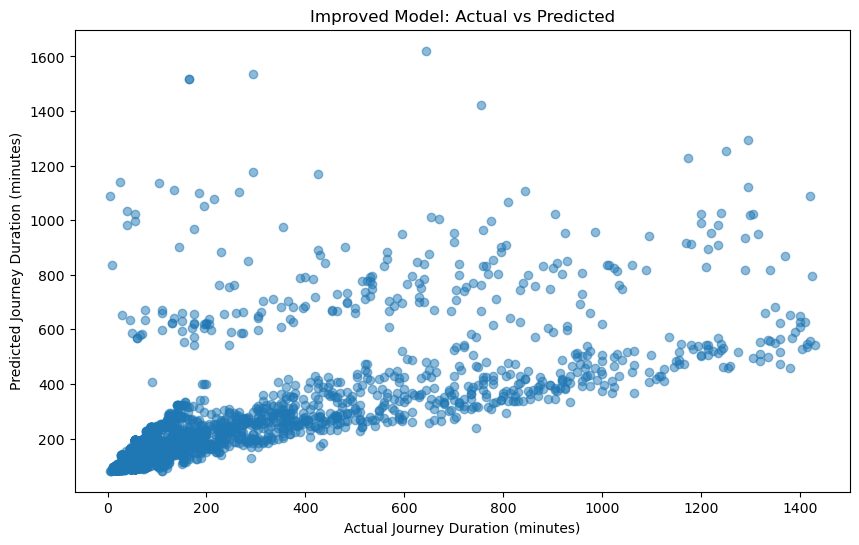

In [28]:
plt.figure(figsize=(10, 6))
plt.scatter(
    y_improved_test,
    y_improved_pred,
    alpha=0.5
)
plt.xlabel("Actual Journey Duration (minutes)")
plt.ylabel("Predicted Journey Duration (minutes)")
plt.title("Improved Model: Actual vs Predicted")

plt.show()

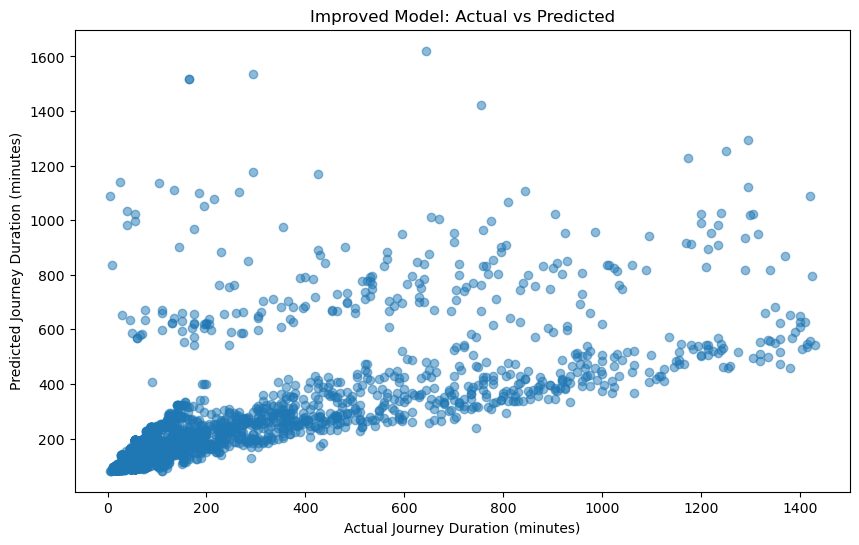

In [29]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_improved_test,
    y_improved_pred,
    alpha=0.5
)
plt.xlabel("Actual Journey Duration (minutes)")
plt.ylabel("Predicted Journey Duration (minutes)")
plt.title("Improved Model: Actual vs Predicted")

plt.show()

In [30]:
import joblib
joblib.dump(
    improved_model,
    "improved_linear_regression_model.pkl"
)
print("Improved model saved successfully!")

Improved model saved successfully!


In [31]:
model_comparison.to_csv(
    "level5_model_comparison.csv",
    index=False
)
print("Level 5 comparison saved successfully!")

Level 5 comparison saved successfully!


In [32]:
model_comparison

,Model,Features,MAE,RMSE
0,Basic Model,Total_Distance,168.802017,247.059450
1,Improved Model,Total_Distance + Number_of_Stops,152.212150,237.386718


In [35]:
import streamlit as st
import joblib
import pandas as pd
model = joblib.load("improved_linear_regression_model.pkl")

In [ ]:
## Level 5 Conclusion

Two Linear Regression models were developed and compared.

The Basic Model used Total_Distance as the input feature, while the Improved Model used Total_Distance and Number_of_Stops.

The Basic Model achieved an MAE of 168.80 minutes and an RMSE of 247.06 minutes.

The Improved Model achieved an MAE of 152.21 minutes and an RMSE of 237.39 minutes.

The Improved Model produced lower MAE and RMSE values on the test dataset. Therefore, the Improved Model was selected for the next stage of the project based on these evaluation metrics.